<a href="https://colab.research.google.com/github/ankan-git-coder/Deep-learning-COURSE/blob/main/fashion_MNIST_pytorch_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

In [19]:
torch.manual_seed(42)
np.random.seed(42)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on {device}.")

Running on cuda.


In [21]:
import torchvision.transforms as transforms

In [22]:
transform = transforms.Compose([transforms.ToTensor()])

In [23]:
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)

In [24]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)


In [25]:
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

In [26]:
testloader = torch.utils.data.DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)


In [27]:
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

In [28]:
print(trainset.data.shape)

torch.Size([60000, 28, 28])


In [30]:
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self):
        super(BasicCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        x= x.view(-1, 64 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)




In [31]:
model = BasicCNN().to(device)

In [32]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [33]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    for images, labels in trainloader:
        images , labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


In [37]:
import numpy as np
from sklearn.metrics import classification_report , confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds =[]
all_labels = []

with torch.no_grad():
    for images , labels in testloader:
        images , labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [39]:
print(classification_report(all_labels, all_preds, target_names=classes))


              precision    recall  f1-score   support

 T-shirt/top       0.86      0.85      0.86      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.88      0.84      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.88      0.79      0.83      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.72      0.73      0.72      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [40]:
cm = confusion_matrix(all_labels, all_preds)

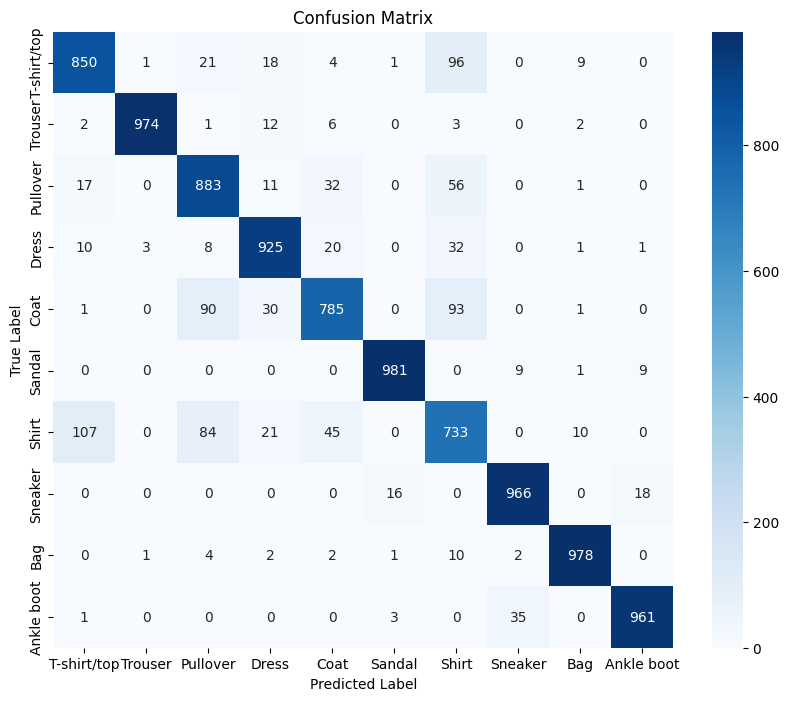

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap=plt.cm.Blues, xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')  # x-axis label
plt.ylabel('True Label')       # y-axis label
plt.title('Confusion Matrix')  # Title of the plot
plt.show()                     # Display the plot


In [42]:
# regularization with dropout

In [43]:
class NetDropout(nn.Module):
    def __init__(self):
        super(NetDropout, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # Output shape: [batch_size, 32, 28, 28]
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # Output shape: [batch_size, 64, 14, 14]

        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0) # Reduces spatial dimensions by half

        # Dropout layer
        self.dropout = nn.Dropout(0.25)  # Helps prevent overfitting

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 512)  # Flattened input to 512 output features
        self.fc2 = nn.Linear(512, 10)          # 512 input features to 10 output classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x))) # Shape: [batch_size, 64, 7, 7]

        x = x.view(-1, 64 * 7 * 7)  # Flatten the tensor
        x = self.dropout(x)         # Apply dropout

        x = F.relu(self.fc1(x))     # First fully connected layer with ReLU activation
        x = self.fc2(x)             # Second fully connected layer


        return x

# Instantiate the model with dropout
model_dropout = NetDropout().to(device)
model_dropout


NetDropout(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)

In [44]:
optimizer = torch.optim.Adam(model_dropout.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [45]:
num_epochs = 5

# Start the training loop
for epoch in range(num_epochs):
    # Initialize a variable to keep track of the cumulative loss for this epoch
    running_loss = 0.0

    # Set the model to training mode
    model_dropout.train()

    # Iterate over each batch of the training data
    for i, (images, labels) in enumerate(trainloader):
        # Move the images and labels to the computational device (CPU or GPU)
        images, labels = images.to(device), labels.to(device)

        # Clear the gradients from the previous iteration
        optimizer.zero_grad()

        # Forward pass: Pass the images through the model to get the predicted outputs
        outputs = model_dropout(images)

        # Compute the loss between the predicted outputs and the true labels
        loss = criterion(outputs, labels)

        # Backward pass: Compute the gradient of the loss w.r.t. model parameters
        loss.backward()

        # Update the model parameters
        optimizer.step()

        # Update the running loss
        running_loss += loss.item()

    # Print the average loss for this epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}")

print("Finished Training")

Epoch [1/5], Loss: 0.3896
Epoch [2/5], Loss: 0.2736
Epoch [3/5], Loss: 0.2465
Epoch [4/5], Loss: 0.2236
Epoch [5/5], Loss: 0.2078
Finished Training


In [46]:
# data augmentation


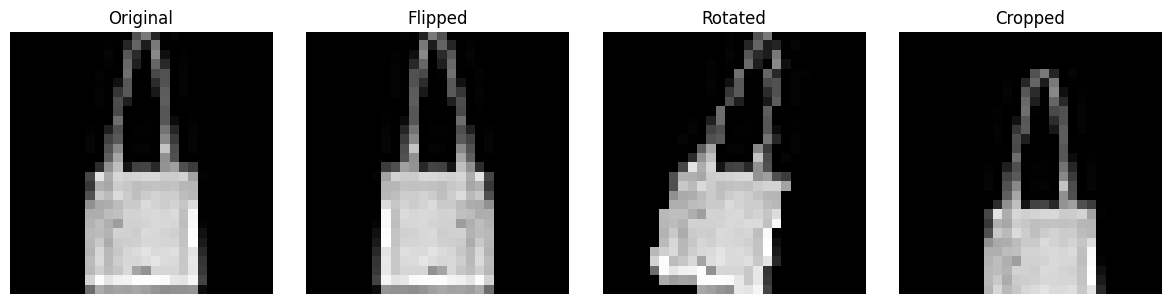

In [52]:
dataset = datasets.FashionMNIST(root='./data', train=True, download=True)

# Fetch a single image for demonstration
image, _ = dataset[200]

# Define the augmentations
transform_flip = transforms.RandomHorizontalFlip(p=1)  # force flip every time
transform_rotate = transforms.RandomRotation(20)
transform_crop = transforms.RandomCrop(28, padding=4)

# Apply the augmentations
image_flip = transform_flip(image)
image_rotate = transform_rotate(image)
image_crop = transform_crop(image)

# Visualize the original and augmented images
fig, axs = plt.subplots(1, 4, figsize=(12, 3))

axs[0].imshow(image, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')

axs[1].imshow(image_flip, cmap='gray')
axs[1].set_title('Flipped')
axs[1].axis('off')

axs[2].imshow(image_rotate, cmap='gray')
axs[2].set_title('Rotated')
axs[2].axis('off')

axs[3].imshow(image_crop, cmap='gray')
axs[3].set_title('Cropped')
axs[3].axis('off')

plt.tight_layout()
plt.show()